# B3 — Ordinal Mapping

---

## 🔍 Problem-এ কী চাওয়া হয়েছে?

আমাদের কাছে একটি `Education` column আছে:

$$\text{Education} = [\text{High School, Bachelor, Master, Bachelor, Master}]$$

তিনটি কাজ করতে হবে:

| Task | কী করতে হবে |
|---|---|
| **১** | **Mapping A** apply করা: High School=0, Bachelor=1, Master=2 |
| **২** | **Mapping B** apply করা: High School=1, Bachelor=2, Master=3 |
| **৩** | এক লাইনে বলা — Mapping পরিবর্তনে **distance কীভাবে shift হয়** |


---

## 🎯 এই কাজ থেকে আমরা কী অর্জন করতে পারব?

- Ordinal Encoding-এ **mapping কীভাবে করতে হয়** সেটার mechanics বুঝব।
- দুটো mapping-এর encoded value আলাদা হলেও **relative distance একই থাকে** — এই গুরুত্বপূর্ণ property বুঝব।
- Mapping-এর starting point (0 বা 1) পরিবর্তন করলে **absolute value বদলায়, কিন্তু ক্রম ও ব্যবধান বদলায় না** — এটা সংখ্যায় প্রমাণ করব।


---

## 🧠 আমরা যা শিখেছি, সেই আলোকে কীভাবে চিন্তা করতে হবে?

### Ordinal Encoding-এর মূল নিয়ম:
- Ordinal data-তে **স্বাভাবিক ক্রম** আছে: High School < Bachelor < Master
- সেই ক্রম অনুযায়ী সংখ্যা assign করা হয় — ছোট সংখ্যা = নিচের স্তর

### দুটো Mapping তুলনা:

| Level | Mapping A | Mapping B | পার্থক্য |
|---|---|---|---|
| High School | 0 | 1 | +1 |
| Bachelor | 1 | 2 | +1 |
| Master | 2 | 3 | +1 |

**লক্ষ্য করো:** Mapping B = Mapping A + 1 — সব মানে একই পরিমাণ (+1) যোগ হয়েছে।

### Distance-এ কী হয়?

Mapping A-তে: Bachelor − High School = **1 − 0 = 1**
Mapping B-তে: Bachelor − High School = **2 − 1 = 1**

**Distance একই থাকে!** কারণ দুটো মানেই একই পরিমাণ (+1) যোগ হয়েছে — বিয়োগ করলে সেটা cancel হয়।

এটাকে বলে **constant shift** — relative distance-এ কোনো প্রভাব পড়ে না।


---

## 🛠️ Problem Solve করার Approach

**Step 1:** Education data তৈরি করা।

**Step 2:** Mapping A apply করা (0, 1, 2)।

**Step 3:** Mapping B apply করা (1, 2, 3)।

**Step 4:** দুটো mapping-এর pairwise distance তুলনা করে দেখানো।

**Step 5:** এক লাইনে explain করা।


## Step 1: Data তৈরি করা

In [1]:
import pandas as pd
import numpy as np

education = ['High School', 'Bachelor', 'Master', 'Bachelor', 'Master']
df = pd.DataFrame({'Education': education})

print("Original data:")
print(df.to_string())
print()
print(f"Unique levels : {df['Education'].unique()}")
print(f"Natural order : High School < Bachelor < Master")


Original data:
     Education
0  High School
1     Bachelor
2       Master
3     Bachelor
4       Master

Unique levels : ['High School' 'Bachelor' 'Master']
Natural order : High School < Bachelor < Master


`Education` column-এ ৩টি unique level আছে — স্পষ্ট natural order বিদ্যমান।
এটি **Ordinal** data — তাই Ordinal Encoding সঠিক।


---

## Step 2: Mapping A — High School=0, Bachelor=1, Master=2

### হাতের হিসাব:

| Row | Education | Encoded |
|---|---|---|
| 1 | High School | **0** |
| 2 | Bachelor | **1** |
| 3 | Master | **2** |
| 4 | Bachelor | **1** |
| 5 | Master | **2** |


In [2]:
mapping_a = {'High School': 0, 'Bachelor': 1, 'Master': 2}

df['Mapping_A'] = df['Education'].map(mapping_a)

print("── Mapping A (High School=0, Bachelor=1, Master=2) ──")
print(df[['Education', 'Mapping_A']].to_string(index=False))


── Mapping A (High School=0, Bachelor=1, Master=2) ──
  Education  Mapping_A
High School          0
   Bachelor          1
     Master          2
   Bachelor          1
     Master          2


`dict` দিয়ে mapping তৈরি করা হয়েছে — key হলো category, value হলো encoded number।
`.map(mapping_a)` → প্রতিটি row-এর Education value-কে dict অনুযায়ী সংখ্যায় রূপান্তর করে।


---

## Step 3: Mapping B — High School=1, Bachelor=2, Master=3

### হাতের হিসাব:

| Row | Education | Encoded |
|---|---|---|
| 1 | High School | **1** |
| 2 | Bachelor | **2** |
| 3 | Master | **3** |
| 4 | Bachelor | **2** |
| 5 | Master | **3** |


In [3]:
mapping_b = {'High School': 1, 'Bachelor': 2, 'Master': 3}

df['Mapping_B'] = df['Education'].map(mapping_b)

print("── Mapping B (High School=1, Bachelor=2, Master=3) ──")
print(df[['Education', 'Mapping_A', 'Mapping_B']].to_string(index=False))
print()
print("Relationship: Mapping_B = Mapping_A + 1")
print(f"Verify: {(df['Mapping_B'] == df['Mapping_A'] + 1).all()}")


── Mapping B (High School=1, Bachelor=2, Master=3) ──
  Education  Mapping_A  Mapping_B
High School          0          1
   Bachelor          1          2
     Master          2          3
   Bachelor          1          2
     Master          2          3

Relationship: Mapping_B = Mapping_A + 1
Verify: True


`Mapping_B = Mapping_A + 1` — এটি একটি **constant shift** (+1)।
`(df['Mapping_B'] == df['Mapping_A'] + 1).all()` → সব row-এ এই সম্পর্ক সত্য কিনা confirm করে।


---

## Step 4: Pairwise Distance তুলনা — Mapping পরিবর্তনে কী হয়?


In [4]:
levels = ['High School', 'Bachelor', 'Master']
enc_a  = [0, 1, 2]
enc_b  = [1, 2, 3]

pairs = [
    ('High School', 'Bachelor'),
    ('Bachelor',    'Master'),
    ('High School', 'Master')
]

rows = []
for l1, l2 in pairs:
    i1, i2   = levels.index(l1), levels.index(l2)
    dist_a   = abs(enc_a[i2] - enc_a[i1])
    dist_b   = abs(enc_b[i2] - enc_b[i1])
    rows.append({
        'Pair':              f'{l1}  ↔  {l2}',
        'Distance (Map A)':  dist_a,
        'Distance (Map B)':  dist_b,
        'Same?':             '✅ Yes' if dist_a == dist_b else '❌ No'
    })

result = pd.DataFrame(rows)
print("── Pairwise Distances: Mapping A vs Mapping B ──")
print(result.to_string(index=False))


── Pairwise Distances: Mapping A vs Mapping B ──
                    Pair  Distance (Map A)  Distance (Map B) Same?
High School  ↔  Bachelor                 1                 1 ✅ Yes
     Bachelor  ↔  Master                 1                 1 ✅ Yes
  High School  ↔  Master                 2                 2 ✅ Yes


`abs(enc_a[i2] - enc_a[i1])` → দুটো level-এর encoded value-এর absolute পার্থক্য = distance।

**সব pair-এ distance একই** — কারণ constant shift (+1) বিয়োগ করার সময় cancel হয়ে যায়:
$(2-1) - (1-0) = 1 - 1 = 0$ → কোনো পরিবর্তন নেই।


---

## Step 5: এক লাইনে Explain

> **Mapping B = Mapping A + 1 — এটি একটি constant shift; দুটো যেকোনো level-এর মধ্যে বিয়োগ করলে +1 cancel হয়ে যায়, তাই pairwise distance হুবহু একই থাকে।**

### সংক্ষেপে:

| পরিবর্তন হয় | পরিবর্তন হয় না |
|---|---|
| Absolute encoded value (0→1, 1→2, 2→3) | দুটো level-এর মধ্যে **relative distance** |
| Starting point (0 থেকে 1-এ shift) | **ক্রম** (High School < Bachelor < Master) |

**Practical অর্থ:** Mapping A দিয়ে train করা model ও Mapping B দিয়ে train করা model — distance-based calculation-এ **একই result দেবে**।


## Bonus: Visual — Constant Shift দেখা

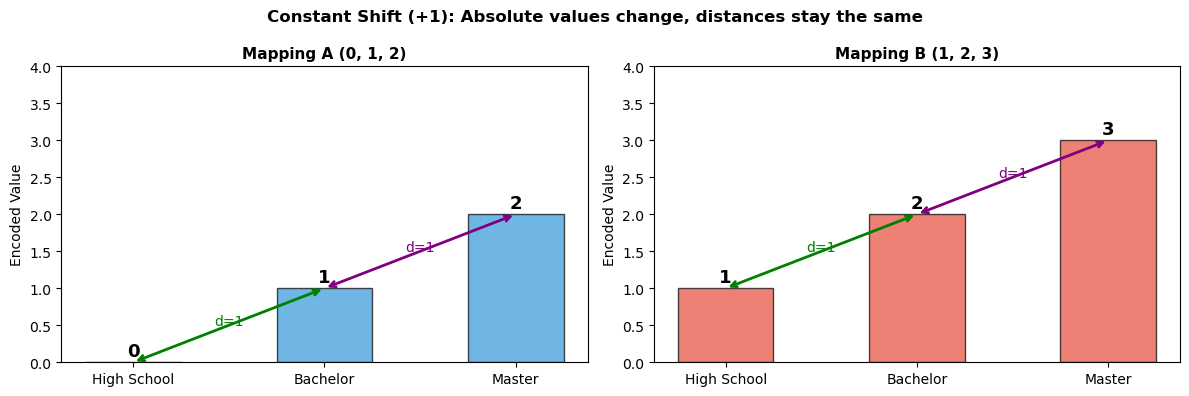

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x_labels = ['High School', 'Bachelor', 'Master']
y_a = [0, 1, 2]
y_b = [1, 2, 3]

for ax, vals, title, color in zip(
    axes,
    [y_a, y_b],
    ['Mapping A (0, 1, 2)', 'Mapping B (1, 2, 3)'],
    ['#3498db', '#e74c3c']
):
    ax.bar(x_labels, vals, color=color, alpha=0.7, edgecolor='black', width=0.5)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Encoded Value')
    ax.set_ylim(0, 4)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.08, str(v), ha='center', fontsize=13, fontweight='bold')

    # annotate distances
    ax.annotate('', xy=(1, vals[1]), xytext=(0, vals[0]),
                arrowprops=dict(arrowstyle='<->', color='green', lw=2))
    ax.text(0.5, (vals[0] + vals[1]) / 2, f'd=1', ha='center', color='green', fontsize=10)

    ax.annotate('', xy=(2, vals[2]), xytext=(1, vals[1]),
                arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
    ax.text(1.5, (vals[1] + vals[2]) / 2, f'd=1', ha='center', color='purple', fontsize=10)

plt.suptitle('Constant Shift (+1): Absolute values change, distances stay the same',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Chart-এ স্পষ্ট দেখা যাচ্ছে:
- **Bar height** বদলেছে — Mapping B সব bar 1 উপরে।
- **Bar-এর মধ্যে ব্যবধান (d=1)** একই আছে — উভয় mapping-এ।

এটাই **constant shift**-এর সারকথা।


---